# DARS vs Glicko-2 Comparison on Bot Student Datasets

This notebook compares the project DARS rating signal against a Glicko-2 baseline using the generated bot-student CSV pack in `datasets/dars`.

The comparison uses `student_test_question_responses.csv` because it contains one row per question inside each adaptive test, with DARS before/after test ratings, question difficulty ratings, response outcomes, timestamps, and test ids. Each adaptive test is treated as one Glicko-2 rating period, which matches the DARS test-level columns in the CSV.

Main outputs:
- predictive metrics: Brier score, log loss, accuracy at 0.5, and ROC AUC
- calibration curves for DARS and Glicko-2
- per-student comparison table
- final rating scatter between DARS and Glicko-2


In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
DATA_DIR = ROOT / "datasets" / "dars"

BOT_STUDENTS_CSV = DATA_DIR / "bot_students_fte455.csv"
TEST_RESPONSES_CSV = DATA_DIR / "student_test_question_responses.csv"
TEST_SESSIONS_CSV = DATA_DIR / "student_test_sessions.csv"
SNAPSHOTS_CSV = DATA_DIR / "student_performance_snapshots.csv"
SUMMARY_OUTPUT_CSV = DATA_DIR / "dars_vs_glicko2_comparison_summary.csv"
STUDENT_OUTPUT_CSV = DATA_DIR / "dars_vs_glicko2_student_metrics.csv"

GLICKO2_SCALE = 173.7178
GLICKO2_INITIAL_RD = 350.0
GLICKO2_INITIAL_VOL = 0.06
GLICKO2_TAU = 0.5
ITEM_RD = 80.0
EPSILON = 1e-6

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


## Load and Validate Data


In [2]:
students = pd.read_csv(BOT_STUDENTS_CSV)
responses_raw = pd.read_csv(TEST_RESPONSES_CSV)
sessions = pd.read_csv(TEST_SESSIONS_CSV)
snapshots = pd.read_csv(SNAPSHOTS_CSV)

responses = responses_raw.copy()
responses = responses[responses["attempted"].eq(1)].copy()
responses["correctness"] = pd.to_numeric(responses["correctness"], errors="coerce")
responses = responses[responses["correctness"].isin([0, 1])].copy()

numeric_cols = [
    "question_order",
    "response_time",
    "DARS_rating_before_test",
    "DARS_rating_after_test",
    "question_elo",
    "correctness",
]
for col in numeric_cols:
    responses[col] = pd.to_numeric(responses[col], errors="coerce")

responses["timestamp_start"] = pd.to_datetime(responses["timestamp_start"], errors="coerce")
responses = responses.dropna(
    subset=["timestamp_start", "DARS_rating_before_test", "DARS_rating_after_test", "question_elo", "correctness"]
)
responses = responses.merge(
    students[["user_id", "starting_rating", "persona"]],
    on="user_id",
    how="left",
    validate="many_to_one",
)
responses = responses.sort_values(["user_id", "timestamp_start", "test_id", "question_order"]).reset_index(drop=True)

print(f"Bot students: {students['user_id'].nunique():,}")
print(f"Attempted question responses used: {len(responses):,}")
print(f"Adaptive tests represented: {responses['test_id'].nunique():,}")
print(f"Questions represented: {responses['question_id'].nunique():,}")

missing = responses[["starting_rating", "persona"]].isna().sum()
if missing.any():
    raise ValueError(f"Missing merged student metadata: {missing.to_dict()}")

responses.head()


Bot students: 220
Attempted question responses used: 70,672
Adaptive tests represented: 1,683
Questions represented: 803


,user_id,test_id,question_order,question_id,course_join_code,test_type,adaptive_mix_label,question_count_in_test,timestamp_start,timestamp_end,...,topic,topic_id,subject_id,difficulty_label,question_elo,graph_hop_distance,remediation_flag,recommendation_source,starting_rating,persona
0,stu_fte455_001,stu_fte455_001_adaptive_mix_01,1,la-32,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:13:41.718000+00:00,2026-02-01T10:15:40.718Z,...,Eigenvalues & Eigenvectors,la-eigenvalues,linear-algebra,Hard,1360,0,0,fallback,1331,steady_improver
1,stu_fte455_001,stu_fte455_001_adaptive_mix_01,2,la-33,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:15:40.718000+00:00,2026-02-01T10:18:10.718Z,...,Eigenvalues & Eigenvectors,la-eigenvalues,linear-algebra,Hard,1360,1,0,Graph route,1331,steady_improver
2,stu_fte455_001,stu_fte455_001_adaptive_mix_01,3,la-43,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:18:10.718000+00:00,2026-02-01T10:19:59.718Z,...,Eigenvalues & Eigenvectors,la-eigenvalues,linear-algebra,Hard,1360,1,1,Graph route,1331,steady_improver
3,stu_fte455_001,stu_fte455_001_adaptive_mix_01,5,la-4,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:20:36.718000+00:00,2026-02-01T10:22:52.718Z,...,Eigenvalues & Eigenvectors,la-eigenvalues,linear-algebra,Hard,1360,1,0,Graph route,1331,steady_improver
4,stu_fte455_001,stu_fte455_001_adaptive_mix_01,7,mock5-q28,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:23:05.718000+00:00,2026-02-01T10:24:31.718Z,...,Eigenvalues & Eigenvectors,la-eigenvalues,linear-algebra,Medium,1350,1,1,Graph route,1331,steady_improver


## Metric Helpers


In [3]:
def elo_expected(rating: float, item_rating: float) -> float:
    return 1.0 / (1.0 + 10.0 ** ((item_rating - rating) / 400.0))


def clip_prob(values):
    return np.clip(np.asarray(values, dtype=float), 1e-6, 1 - 1e-6)


def brier_score(y_true, y_prob) -> float:
    y = np.asarray(y_true, dtype=float)
    p = clip_prob(y_prob)
    return float(np.mean((p - y) ** 2))


def log_loss(y_true, y_prob) -> float:
    y = np.asarray(y_true, dtype=float)
    p = clip_prob(y_prob)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


def accuracy_at_half(y_true, y_prob) -> float:
    y = np.asarray(y_true, dtype=int)
    p = np.asarray(y_prob, dtype=float)
    return float(np.mean((p >= 0.5).astype(int) == y))


def roc_auc_score_binary(y_true, y_prob) -> float:
    y = np.asarray(y_true, dtype=int)
    p = np.asarray(y_prob, dtype=float)
    positives = y == 1
    negatives = y == 0
    n_pos = int(positives.sum())
    n_neg = int(negatives.sum())
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    order = np.argsort(p)
    sorted_p = p[order]
    ranks = np.empty_like(sorted_p, dtype=float)
    start = 0
    while start < len(sorted_p):
        end = start + 1
        while end < len(sorted_p) and sorted_p[end] == sorted_p[start]:
            end += 1
        ranks[start:end] = (start + 1 + end) / 2.0
        start = end

    original_ranks = np.empty_like(ranks)
    original_ranks[order] = ranks
    rank_sum_pos = original_ranks[positives].sum()
    auc = (rank_sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
    return float(auc)


def metric_row(name: str, frame: pd.DataFrame, prob_col: str) -> dict:
    y = frame["correctness"].astype(float).to_numpy()
    p = frame[prob_col].astype(float).to_numpy()
    return {
        "model": name,
        "n": len(frame),
        "brier": brier_score(y, p),
        "log_loss": log_loss(y, p),
        "accuracy_at_0_5": accuracy_at_half(y, p),
        "roc_auc": roc_auc_score_binary(y, p),
        "mean_predicted_correct": float(np.mean(p)),
        "actual_accuracy": float(np.mean(y)),
    }


## Glicko-2 Implementation


In [4]:
def rating_to_mu(rating: float) -> float:
    return (float(rating) - 1500.0) / GLICKO2_SCALE


def rd_to_phi(rd: float) -> float:
    return float(rd) / GLICKO2_SCALE


def mu_to_rating(mu: float) -> float:
    return 1500.0 + GLICKO2_SCALE * float(mu)


def phi_to_rd(phi: float) -> float:
    return GLICKO2_SCALE * float(phi)


def glicko2_g(phi: float) -> float:
    return 1.0 / math.sqrt(1.0 + 3.0 * phi**2 / math.pi**2)


def glicko2_expected(mu: float, opp_mu: float, opp_phi: float) -> float:
    return 1.0 / (1.0 + math.exp(-glicko2_g(opp_phi) * (mu - opp_mu)))


@dataclass
class Glicko2State:
    rating: float
    rd: float = GLICKO2_INITIAL_RD
    volatility: float = GLICKO2_INITIAL_VOL


def glicko2_prediction(player: Glicko2State, item_rating: float, item_rd: float = ITEM_RD) -> float:
    return glicko2_expected(rating_to_mu(player.rating), rating_to_mu(item_rating), rd_to_phi(item_rd))


def _volatility_f(x: float, delta: float, phi: float, v: float, a: float, tau: float) -> float:
    exp_x = math.exp(x)
    numerator = exp_x * (delta**2 - phi**2 - v - exp_x)
    denominator = 2.0 * (phi**2 + v + exp_x) ** 2
    return numerator / denominator - (x - a) / (tau**2)


def glicko2_update_period(
    player: Glicko2State,
    item_ratings: list[float],
    outcomes: list[float],
    item_rd: float = ITEM_RD,
    tau: float = GLICKO2_TAU,
    epsilon: float = EPSILON,
) -> Glicko2State:
    if not item_ratings:
        phi = rd_to_phi(player.rd)
        phi_star = math.sqrt(phi**2 + player.volatility**2)
        return Glicko2State(player.rating, phi_to_rd(phi_star), player.volatility)

    mu = rating_to_mu(player.rating)
    phi = rd_to_phi(player.rd)
    sigma = player.volatility
    opp_mus = [rating_to_mu(r) for r in item_ratings]
    opp_phi = rd_to_phi(item_rd)
    gs = [glicko2_g(opp_phi) for _ in opp_mus]
    es = [glicko2_expected(mu, opp_mu, opp_phi) for opp_mu in opp_mus]

    v_inv = sum((g**2) * e * (1 - e) for g, e in zip(gs, es))
    if v_inv <= 0:
        return player
    v = 1.0 / v_inv
    delta = v * sum(g * (s - e) for g, s, e in zip(gs, outcomes, es))

    a = math.log(sigma**2)
    if delta**2 > phi**2 + v:
        b = math.log(delta**2 - phi**2 - v)
    else:
        k = 1
        while _volatility_f(a - k * tau, delta, phi, v, a, tau) < 0:
            k += 1
        b = a - k * tau

    f_a = _volatility_f(a, delta, phi, v, a, tau)
    f_b = _volatility_f(b, delta, phi, v, a, tau)
    while abs(b - a) > epsilon:
        c = a + (a - b) * f_a / (f_b - f_a)
        f_c = _volatility_f(c, delta, phi, v, a, tau)
        if f_c * f_b < 0:
            a = b
            f_a = f_b
        else:
            f_a /= 2.0
        b = c
        f_b = f_c

    new_sigma = math.exp(a / 2.0)
    phi_star = math.sqrt(phi**2 + new_sigma**2)
    new_phi = 1.0 / math.sqrt((1.0 / phi_star**2) + (1.0 / v))
    new_mu = mu + new_phi**2 * sum(g * (s - e) for g, s, e in zip(gs, outcomes, es))

    return Glicko2State(
        rating=float(mu_to_rating(new_mu)),
        rd=float(max(30.0, min(350.0, phi_to_rd(new_phi)))),
        volatility=float(new_sigma),
    )


## Replay DARS Predictions and Glicko-2 Rating Periods


In [5]:
work = responses.copy()
work["dars_prob"] = [
    elo_expected(rating, item)
    for rating, item in zip(work["DARS_rating_before_test"], work["question_elo"])
]

glicko_records = []
final_glicko_states = {}

for user_id, student_rows in work.groupby("user_id", sort=False):
    start_rating = float(student_rows["starting_rating"].iloc[0])
    state = Glicko2State(rating=start_rating)

    for test_id, period in student_rows.groupby("test_id", sort=False):
        period = period.sort_values(["timestamp_start", "question_order"])
        rating_before = state.rating
        rd_before = state.rd
        vol_before = state.volatility

        probs = [glicko2_prediction(state, item_rating) for item_rating in period["question_elo"].astype(float)]

        item_ratings = period["question_elo"].astype(float).tolist()
        outcomes = period["correctness"].astype(float).tolist()
        state_after = glicko2_update_period(state, item_ratings, outcomes)

        for row_index, probability in zip(period.index, probs):
            glicko_records.append(
                {
                    "row_index": row_index,
                    "glicko2_prob": probability,
                    "glicko2_rating_before_period": rating_before,
                    "glicko2_rd_before_period": rd_before,
                    "glicko2_vol_before_period": vol_before,
                    "glicko2_rating_after_period": state_after.rating,
                    "glicko2_rd_after_period": state_after.rd,
                    "glicko2_vol_after_period": state_after.volatility,
                }
            )

        state = state_after

    final_glicko_states[user_id] = state

glicko_df = pd.DataFrame(glicko_records).set_index("row_index")
work = work.join(glicko_df, how="left")

print(work[["dars_prob", "glicko2_prob"]].describe().round(4))
work.head()


        dars_prob  glicko2_prob
count  70672.0000    70672.0000
mean       0.6612        0.6137
std        0.1735        0.1502
min        0.0801        0.1093
25%        0.5273        0.5080
50%        0.6813        0.6213
75%        0.8038        0.7258
max        0.9864        0.9559


,user_id,test_id,question_order,question_id,course_join_code,test_type,adaptive_mix_label,question_count_in_test,timestamp_start,timestamp_end,...,starting_rating,persona,dars_prob,glicko2_prob,glicko2_rating_before_period,glicko2_rd_before_period,glicko2_vol_before_period,glicko2_rating_after_period,glicko2_rd_after_period,glicko2_vol_after_period
0,stu_fte455_001,stu_fte455_001_adaptive_mix_01,1,la-32,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:13:41.718000+00:00,2026-02-01T10:15:40.718Z,...,1331,steady_improver,0.458362,0.459637,1331.0,350.0,0.06,1388.522803,59.906224,0.059997
1,stu_fte455_001,stu_fte455_001_adaptive_mix_01,2,la-33,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:15:40.718000+00:00,2026-02-01T10:18:10.718Z,...,1331,steady_improver,0.458362,0.459637,1331.0,350.0,0.06,1388.522803,59.906224,0.059997
2,stu_fte455_001,stu_fte455_001_adaptive_mix_01,3,la-43,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:18:10.718000+00:00,2026-02-01T10:19:59.718Z,...,1331,steady_improver,0.458362,0.459637,1331.0,350.0,0.06,1388.522803,59.906224,0.059997
3,stu_fte455_001,stu_fte455_001_adaptive_mix_01,5,la-4,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:20:36.718000+00:00,2026-02-01T10:22:52.718Z,...,1331,steady_improver,0.458362,0.459637,1331.0,350.0,0.06,1388.522803,59.906224,0.059997
4,stu_fte455_001,stu_fte455_001_adaptive_mix_01,7,mock5-q28,FTE455,adaptive_mix,Adaptive test mix (40),40,2026-02-01 10:23:05.718000+00:00,2026-02-01T10:24:31.718Z,...,1331,steady_improver,0.472684,0.473522,1331.0,350.0,0.06,1388.522803,59.906224,0.059997


## Overall Metrics


In [6]:
overall_metrics = pd.DataFrame(
    [
        metric_row("DARS", work, "dars_prob"),
        metric_row("Glicko-2", work, "glicko2_prob"),
    ]
)

overall_metrics.to_csv(SUMMARY_OUTPUT_CSV, index=False)
overall_metrics.round(5)


,model,n,brier,log_loss,accuracy_at_0_5,roc_auc,mean_predicted_correct,actual_accuracy
0,DARS,70672,0.23948,0.68186,0.61618,0.60250,0.66124,0.61501
1,Glicko-2,70672,0.23235,0.65806,0.61563,0.60867,0.61366,0.61501


## Per-Student Metrics


In [7]:
student_rows = []
for user_id, frame in work.groupby("user_id"):
    if len(frame) < 10:
        continue
    dars = metric_row("DARS", frame, "dars_prob")
    glicko = metric_row("Glicko-2", frame, "glicko2_prob")
    final_state = final_glicko_states[user_id]
    student_rows.append(
        {
            "user_id": user_id,
            "persona": frame["persona"].iloc[0],
            "n": len(frame),
            "actual_accuracy": float(frame["correctness"].mean()),
            "dars_brier": dars["brier"],
            "glicko2_brier": glicko["brier"],
            "brier_delta_glicko_minus_dars": glicko["brier"] - dars["brier"],
            "dars_log_loss": dars["log_loss"],
            "glicko2_log_loss": glicko["log_loss"],
            "log_loss_delta_glicko_minus_dars": glicko["log_loss"] - dars["log_loss"],
            "dars_final_rating": float(frame["DARS_rating_after_test"].iloc[-1]),
            "glicko2_final_rating": final_state.rating,
            "glicko2_final_rd": final_state.rd,
        }
    )

student_metrics = pd.DataFrame(student_rows).sort_values("brier_delta_glicko_minus_dars", ascending=False)
student_metrics.to_csv(STUDENT_OUTPUT_CSV, index=False)

print(
    "Students where DARS has lower Brier score:",
    int((student_metrics["brier_delta_glicko_minus_dars"] > 0).sum()),
    "of",
    len(student_metrics),
)
student_metrics.head(10).round(4)


Students where DARS has lower Brier score: 77 of 220


,user_id,persona,n,actual_accuracy,dars_brier,glicko2_brier,brier_delta_glicko_minus_dars,dars_log_loss,glicko2_log_loss,log_loss_delta_glicko_minus_dars,dars_final_rating,glicko2_final_rating,glicko2_final_rd
145,stu_fte455_146,steady_improver,262,0.6603,0.2331,0.2494,0.0163,0.6594,0.6935,0.0341,1577.0,1553.7314,64.0628
32,stu_fte455_033,slow_analytical,221,0.5837,0.2628,0.2781,0.0154,0.7308,0.7591,0.0283,1488.0,1457.9004,48.2834
134,stu_fte455_135,remediation_responder,205,0.5415,0.2645,0.2784,0.0139,0.7266,0.7627,0.0361,1309.0,1296.5573,71.5568
191,stu_fte455_192,fast_but_careless,249,0.5863,0.2526,0.2661,0.0135,0.7049,0.7310,0.0261,1525.0,1563.0028,69.5205
131,stu_fte455_132,fast_but_careless,198,0.5707,0.2343,0.2475,0.0132,0.6606,0.6882,0.0276,1382.0,1440.0953,57.0808
171,stu_fte455_172,fast_but_careless,209,0.5981,0.2437,0.2536,0.0098,0.6831,0.7083,0.0252,1430.0,1430.0765,49.8549
15,stu_fte455_016,steady_improver,263,0.6730,0.2064,0.2152,0.0088,0.6038,0.6212,0.0174,1628.0,1584.1919,43.4984
82,stu_fte455_083,slow_analytical,341,0.6598,0.2104,0.2187,0.0083,0.6108,0.6318,0.0210,1628.0,1628.2445,54.0765
60,stu_fte455_061,steady_improver,395,0.7165,0.1900,0.1975,0.0076,0.5614,0.5785,0.0171,1743.0,1634.3361,77.4583
146,stu_fte455_147,fast_but_careless,280,0.5179,0.2409,0.2480,0.0071,0.6753,0.6899,0.0147,1318.0,1411.4658,43.0852


## Segment Metrics


In [8]:
segment_tables = []
for segment in ["persona", "difficulty_label", "question_count_in_test", "recommendation_source", "remediation_flag"]:
    rows = []
    for value, frame in work.groupby(segment):
        if len(frame) < 25:
            continue
        dars = metric_row("DARS", frame, "dars_prob")
        glicko = metric_row("Glicko-2", frame, "glicko2_prob")
        rows.append(
            {
                "segment": segment,
                "value": value,
                "n": len(frame),
                "actual_accuracy": float(frame["correctness"].mean()),
                "dars_brier": dars["brier"],
                "glicko2_brier": glicko["brier"],
                "brier_delta_glicko_minus_dars": glicko["brier"] - dars["brier"],
                "dars_log_loss": dars["log_loss"],
                "glicko2_log_loss": glicko["log_loss"],
            }
        )
    segment_tables.append(pd.DataFrame(rows))

segment_metrics = pd.concat(segment_tables, ignore_index=True)
segment_metrics.sort_values(["segment", "value"]).round(4)


,segment,value,n,actual_accuracy,dars_brier,glicko2_brier,brier_delta_glicko_minus_dars,dars_log_loss,glicko2_log_loss
5,difficulty_label,Easy,12973,0.7866,0.1719,0.1682,-0.0037,0.5371,0.5189
6,difficulty_label,Hard,14821,0.4724,0.2678,0.2596,-0.0082,0.7389,0.7160
7,difficulty_label,Medium,42878,0.6124,0.2501,0.2423,-0.0078,0.7059,0.6801
0,persona,fast_but_careless,13878,0.5672,0.2555,0.2452,-0.0102,0.7191,0.6861
1,persona,remediation_responder,13942,0.6165,0.2386,0.2329,-0.0057,0.6798,0.6591
2,persona,slow_analytical,13843,0.6376,0.2317,0.2261,-0.0056,0.6641,0.6441
3,persona,steady_improver,14964,0.6705,0.2218,0.2169,-0.0049,0.6400,0.6245
4,persona,volatile_practicer,14045,0.5794,0.2511,0.2418,-0.0093,0.7092,0.6787
8,question_count_in_test,30,11649,0.6093,0.2439,0.2355,-0.0084,0.6914,0.6656
9,question_count_in_test,40,14865,0.6100,0.2401,0.2326,-0.0075,0.6830,0.6582


## Calibration Curves


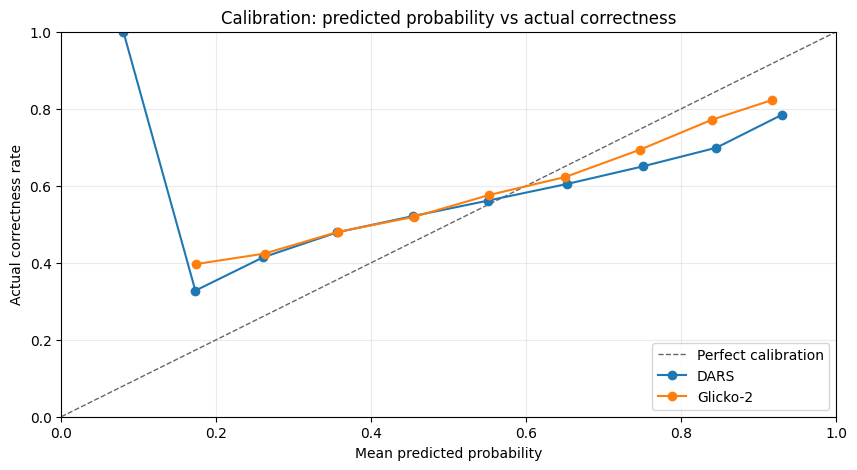

,model,bin,mean_predicted,actual_accuracy,n
0,DARS,"(-0.001, 0.1]",0.0801,1.0000,1
1,DARS,"(0.1, 0.2]",0.1730,0.3275,287
2,DARS,"(0.2, 0.3]",0.2603,0.4139,1312
3,DARS,"(0.3, 0.4]",0.3563,0.4791,3728
4,DARS,"(0.4, 0.5]",0.4541,0.5213,9570
5,DARS,"(0.5, 0.6]",0.5510,0.5615,10178
6,DARS,"(0.6, 0.7]",0.6526,0.6046,13145
7,DARS,"(0.7, 0.8]",0.7500,0.6500,14204
8,DARS,"(0.8, 0.9]",0.8453,0.6987,13479
9,DARS,"(0.9, 1.0]",0.9296,0.7840,4768


In [9]:
def calibration_table(frame: pd.DataFrame, prob_col: str, bins: int = 10) -> pd.DataFrame:
    temp = frame[[prob_col, "correctness"]].copy()
    temp["bin"] = pd.cut(temp[prob_col], bins=np.linspace(0, 1, bins + 1), include_lowest=True)
    return (
        temp.groupby("bin", observed=True)
        .agg(
            mean_predicted=(prob_col, "mean"),
            actual_accuracy=("correctness", "mean"),
            n=("correctness", "size"),
        )
        .reset_index()
    )


dars_cal = calibration_table(work, "dars_prob")
glicko_cal = calibration_table(work, "glicko2_prob")

fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], color="#666666", linestyle="--", linewidth=1, label="Perfect calibration")
ax.plot(dars_cal["mean_predicted"], dars_cal["actual_accuracy"], marker="o", label="DARS")
ax.plot(glicko_cal["mean_predicted"], glicko_cal["actual_accuracy"], marker="o", label="Glicko-2")
ax.set_title("Calibration: predicted probability vs actual correctness")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual correctness rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.show()

pd.concat(
    [
        dars_cal.assign(model="DARS"),
        glicko_cal.assign(model="Glicko-2"),
    ],
    ignore_index=True,
)[["model", "bin", "mean_predicted", "actual_accuracy", "n"]].round(4)


## Metric and Rating Visuals


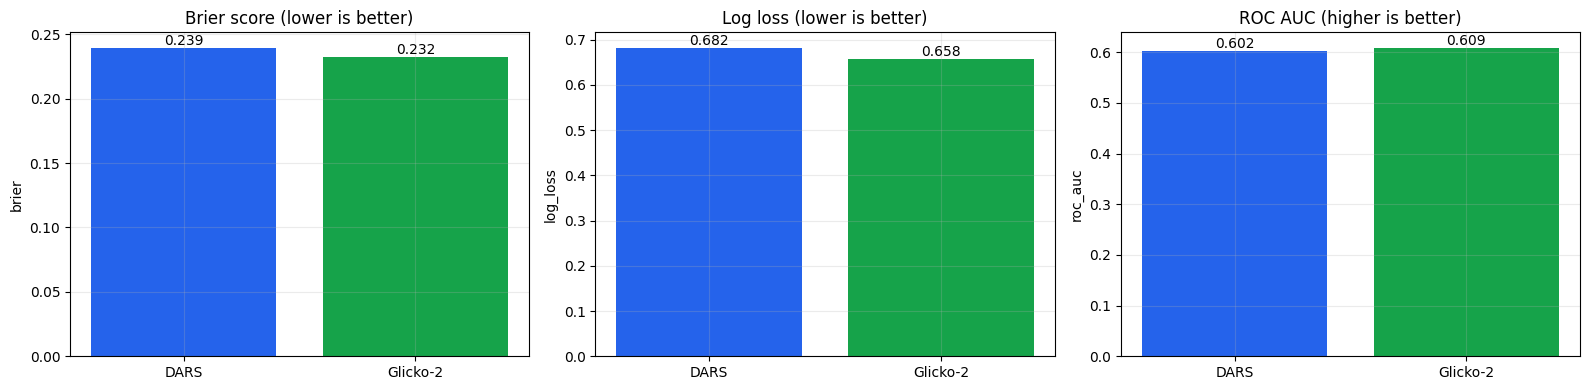

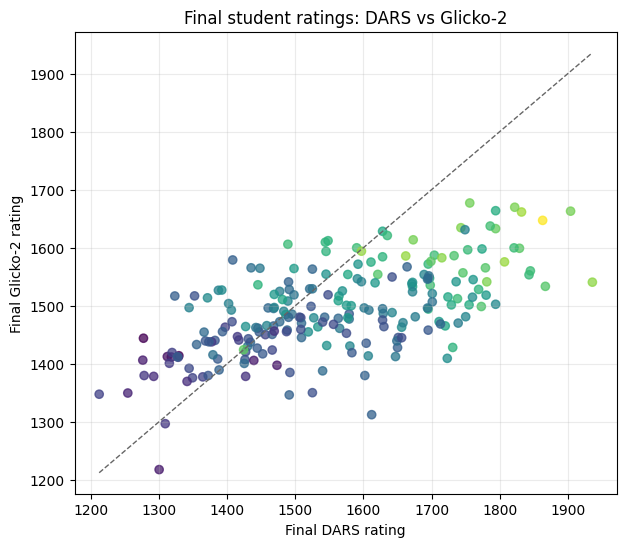

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, title in zip(
    axes,
    ["brier", "log_loss", "roc_auc"],
    ["Brier score (lower is better)", "Log loss (lower is better)", "ROC AUC (higher is better)"],
):
    ax.bar(overall_metrics["model"], overall_metrics[metric], color=["#2563eb", "#16a34a"])
    ax.set_title(title)
    ax.set_ylabel(metric)
    for idx, value in enumerate(overall_metrics[metric]):
        ax.text(idx, value, f"{value:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    student_metrics["dars_final_rating"],
    student_metrics["glicko2_final_rating"],
    c=student_metrics["actual_accuracy"],
    cmap="viridis",
    alpha=0.75,
)
low = min(student_metrics["dars_final_rating"].min(), student_metrics["glicko2_final_rating"].min())
high = max(student_metrics["dars_final_rating"].max(), student_metrics["glicko2_final_rating"].max())
ax.plot([low, high], [low, high], color="#666666", linestyle="--", linewidth=1)
ax.set_title("Final student ratings: DARS vs Glicko-2")
ax.set_xlabel("Final DARS rating")
ax.set_ylabel("Final Glicko-2 rating")
plt.show()


## Quick Interpretation Scaffold


In [11]:
dars_brier = float(overall_metrics.loc[overall_metrics["model"].eq("DARS"), "brier"].iloc[0])
glicko_brier = float(overall_metrics.loc[overall_metrics["model"].eq("Glicko-2"), "brier"].iloc[0])
dars_ll = float(overall_metrics.loc[overall_metrics["model"].eq("DARS"), "log_loss"].iloc[0])
glicko_ll = float(overall_metrics.loc[overall_metrics["model"].eq("Glicko-2"), "log_loss"].iloc[0])

winner_brier = "DARS" if dars_brier < glicko_brier else "Glicko-2"
winner_logloss = "DARS" if dars_ll < glicko_ll else "Glicko-2"

print(f"Brier winner: {winner_brier} (DARS={dars_brier:.4f}, Glicko-2={glicko_brier:.4f})")
print(f"Log-loss winner: {winner_logloss} (DARS={dars_ll:.4f}, Glicko-2={glicko_ll:.4f})")
print(f"Saved overall metrics to: {SUMMARY_OUTPUT_CSV}")
print(f"Saved per-student metrics to: {STUDENT_OUTPUT_CSV}")

segment_metrics.sort_values("brier_delta_glicko_minus_dars", ascending=False).head(12).round(4)


Brier winner: Glicko-2 (DARS=0.2395, Glicko-2=0.2323)
Log-loss winner: Glicko-2 (DARS=0.6819, Glicko-2=0.6581)
Saved overall metrics to: c:\Users\sunil\Downloads\btech-project\datasets\dars\dars_vs_glicko2_comparison_summary.csv
Saved per-student metrics to: c:\Users\sunil\Downloads\btech-project\datasets\dars\dars_vs_glicko2_student_metrics.csv


,segment,value,n,actual_accuracy,dars_brier,glicko2_brier,brier_delta_glicko_minus_dars,dars_log_loss,glicko2_log_loss
13,recommendation_source,fallback,2964,0.4983,0.2570,0.2553,-0.0016,0.7097,0.7054
5,difficulty_label,Easy,12973,0.7866,0.1719,0.1682,-0.0037,0.5371,0.5189
3,persona,steady_improver,14964,0.6705,0.2218,0.2169,-0.0049,0.6400,0.6245
11,question_count_in_test,65,25088,0.6185,0.2368,0.2312,-0.0056,0.6753,0.6555
2,persona,slow_analytical,13843,0.6376,0.2317,0.2261,-0.0056,0.6641,0.6441
1,persona,remediation_responder,13942,0.6165,0.2386,0.2329,-0.0057,0.6798,0.6591
15,remediation_flag,1,25980,0.5912,0.2459,0.2400,-0.0059,0.6942,0.6745
12,recommendation_source,Graph route,67708,0.6201,0.2387,0.2313,-0.0074,0.6806,0.6560
9,question_count_in_test,40,14865,0.6100,0.2401,0.2326,-0.0075,0.6830,0.6582
7,difficulty_label,Medium,42878,0.6124,0.2501,0.2423,-0.0078,0.7059,0.6801


## Notes for Reporting

- This is a simulated bot-student benchmark, so report it as a controlled validation dataset, not as evidence from live learners.
- DARS uses education-specific signals stored in the CSVs: response time, rapid guessing, momentum, graph routing, remediation, and the adaptive mix test context.
- Glicko-2 is used as an uncertainty-aware rating baseline. It sees correctness and item difficulty, but not the extra educational signals.
- If you later add real student logs, rerun the same notebook on those CSVs and compare whether the same model ranking holds.
